In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
plt.style.use("seaborn-v0_8")

In [31]:
prices_raw = pd.read_csv("prices_round_1_day_0.csv", sep = ";", index_col = "timestamp")

In [32]:
ipr = prices_raw[prices_raw["product"] != "ASH_COATED_OSMIUM"]
ipr = ipr.copy()
ipr

,day,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
timestamp,,,,,,,,,,,,,,,,
0,0,INTARIAN_PEPPER_ROOT,11991.0,19.0,NaN,NaN,NaN,NaN,12006.0,10.0,12009.0,19.0,NaN,NaN,11998.5,0.0
100,0,INTARIAN_PEPPER_ROOT,11994.0,9.0,11991.0,23.0,NaN,NaN,12007.0,9.0,12010.0,23.0,NaN,NaN,12000.5,0.0
200,0,INTARIAN_PEPPER_ROOT,11991.0,20.0,NaN,NaN,NaN,NaN,12007.0,11.0,12010.0,20.0,NaN,NaN,11999.0,0.0
300,0,INTARIAN_PEPPER_ROOT,11994.0,10.0,11991.0,24.0,NaN,NaN,12007.0,10.0,NaN,NaN,NaN,NaN,12000.5,0.0
400,0,INTARIAN_PEPPER_ROOT,11994.0,12.0,11991.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11994.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999500,0,INTARIAN_PEPPER_ROOT,12989.0,19.0,NaN,NaN,NaN,NaN,13006.0,12.0,NaN,NaN,NaN,NaN,12997.5,0.0
999600,0,INTARIAN_PEPPER_ROOT,12993.0,8.0,NaN,NaN,NaN,NaN,13007.0,8.0,13010.0,25.0,NaN,NaN,13000.0,0.0
999700,0,INTARIAN_PEPPER_ROOT,12989.0,20.0,NaN,NaN,NaN,NaN,13007.0,10.0,13010.0,20.0,NaN,NaN,12998.0,0.0


In [33]:
intercept = ipr.day * 1000 + 12000
ipr["true_price"] = 0.001 * ipr.index + intercept
ipr["true_price"]

timestamp
0         12000.0
100       12000.1
200       12000.2
300       12000.3
400       12000.4
           ...   
999500    12999.5
999600    12999.6
999700    12999.7
999800    12999.8
999900    12999.9
Name: true_price, Length: 10000, dtype: float64

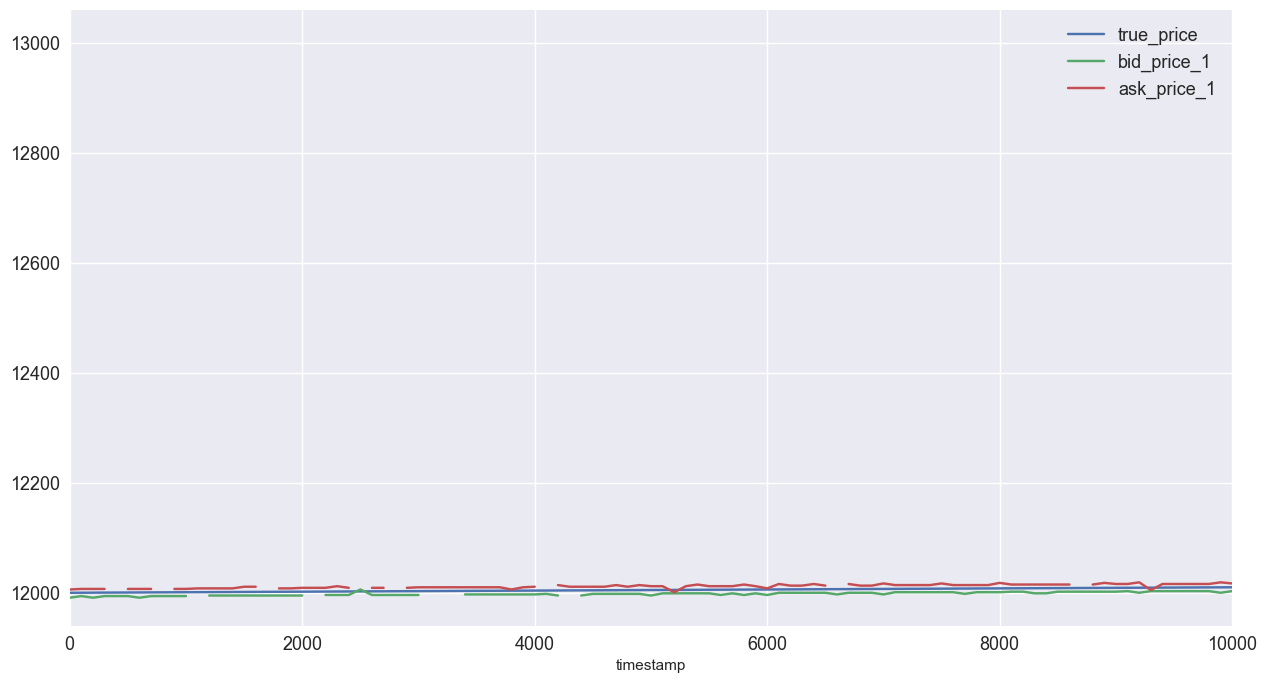

In [39]:
start = 0
window = 10000
range = [start, start + window]

ipr[["true_price", "bid_price_1", "ask_price_1"]].plot(figsize = (15, 8), fontsize = 13, xlim=(range[0], range[1]))
plt.legend(fontsize = 13)
plt.show()

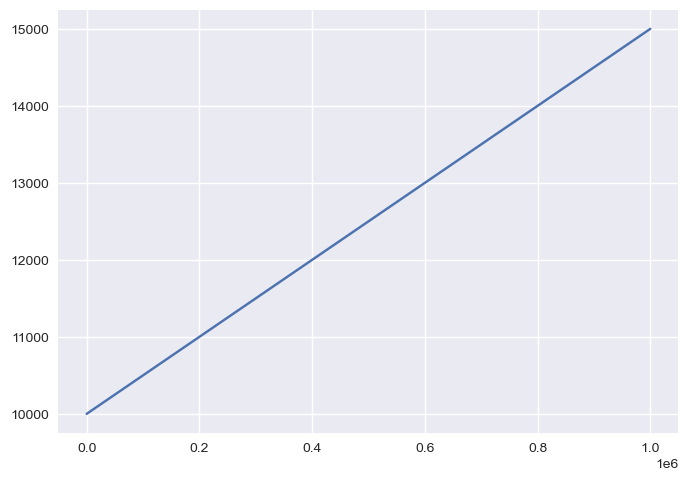

In [20]:
x_model = np.arange(0, 1000000, 100)
y_model = 0.005 * x_model + 10000
plt.plot(x_model, y_model)
plt.show()